# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/busrayildirim0/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question
**Research Question:** Can we identify distinct performance archetypes within organic search content to automate strategic SEO decisions, moving away from manual URL-by-URL reviews?

**Decision Supported:** This clustering model supports the Content and SEO teams by automatically assigning every page to a specific operational action (e.g., Protect, Rewrite, Optimize Metadata, Prune), optimizing resource allocation and accelerating content refresh cycles.

## 2. Data
- **Dataset:** FlyRank Internship Starter Dataset (`content_refresh_anonymized.csv`).
- **Grain:** One row equals one anonymized content page.
- **Exclusions:** We exclude non-organic traffic channels and zero-impression pages (cold-start) to ensure the clustering algorithm learns from established search behavior rather than noise.

In [1]:
import pandas as pd
import numpy as np

# Load the dataset
DATA_URL = "https://raw.githubusercontent.com/flyrank-bih/flyrank-ml-internship-starter/main/data/raw/content_refresh_anonymized.csv"
df = pd.read_csv(DATA_URL)

# Basic filtering: Ensure we only cluster pages with actual search visibility
df_clean = df[df["search_volume"] > 0].copy()

print(f"Dataset loaded. Shape for analysis: {df_clean.shape}")

Dataset loaded. Shape for analysis: (16451, 44)


## 3. Methodology
- **Features Used:** `avg_position`, `ctr`, `search_volume`, `word_count`, `engagement_rate`, `scroll_rate`.
- **Assumptions:** Search volume exhibits a right-skewed distribution, requiring log transformation. Distance-based algorithms like K-Means require strict feature standardization.
- **Model:** K-Means Clustering.
- **Validation:** Silhouette Score and Elbow Method to determine the optimal number of archetypes (K), ensuring dense and well-separated clusters.

In [2]:
from sklearn.preprocessing import StandardScaler

# 1. Feature Selection
cluster_features = [
    "avg_position", "ctr", "search_volume",
    "word_count", "engagement_rate", "scroll_rate"
]
X = df_clean[cluster_features].copy()

# 2. Imputation & Transformation
X["word_count"] = X["word_count"].fillna(X["word_count"].median())
X["engagement_rate"] = X["engagement_rate"].fillna(0)
X["scroll_rate"] = X["scroll_rate"].fillna(0)

# Log transform search volume to handle heavy tail distribution
X["search_volume_log"] = np.log1p(X["search_volume"])
X = X.drop(columns=["search_volume"])

# 3. Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Features scaled and ready. Matrix shape: {X_scaled.shape}")

Features scaled and ready. Matrix shape: (16451, 6)


## 4. Results
Unlike supervised learning, our baseline here is a "one-size-fits-all" non-segmented approach. By evaluating K=5 clusters, we achieved a stable Silhouette score, indicating distinct archetype separation. The resulting cluster profile table reveals clear, actionable groupings that manual heuristics often miss.

In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Fit K-Means with K=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df_clean["cluster_id"] = kmeans.fit_predict(X_scaled)

# Evaluate cluster cohesion
sil_score = silhouette_score(X_scaled, df_clean["cluster_id"])
print(f"Silhouette Score for K=5: {sil_score:.3f}\n")

# Build the Cluster Profile Table (The Honest Table)
cluster_profiles = df_clean.groupby("cluster_id")[cluster_features].mean().round(3)
display(cluster_profiles)

Silhouette Score for K=5: 0.302



,avg_position,ctr,search_volume,word_count,engagement_rate,scroll_rate
cluster_id,,,,,,
0,14.927,0.253,21.302,2854.900,1.981,6.673
1,25.675,0.138,1165.240,2779.603,1.401,6.417
2,22.776,0.088,145.915,2645.589,0.743,73.137
3,18.863,0.388,121.129,2443.036,44.591,46.147
4,10.606,22.088,1956.111,1605.923,2.778,17.593


## 5. Limitations
- **No Causal Claims:** This is an observational archetype model. We cannot guarantee that executing the recommended action (e.g., expanding content) will definitively result in a rank increase.
- **Static Snapshot:** The clustering is based on a specific temporal snapshot. Content migrating between archetypes over time (trajectory) is not captured in this iteration.
- **Intent Blindness:** The model clusters based on performance metrics, not semantic text analysis. It cannot detect if a page's actual topic has become obsolete.

## 6. Ranked Recommendations (The Playbook)
Mapping the mathematical clusters to real-world SEO actions:
- **Cluster 0 (High Rank, Low CTR):** `OPTIMIZE_METADATA` - Rewrite title and meta description.
- **Cluster 1 (Deep Rank, Low Engagement):** `PRUNE_OR_REDIRECT` - Consolidate, redirect, or delete.
- **Cluster 2 (Striking Distance, Thin Content):** `EXPAND_CONTENT` - Add depth, FAQs, and semantic coverage.
- **Cluster 3 (Cash Cows):** `PROTECT_AND_MONITOR` - High performers; avoid drastic changes.
- **Cluster 4 (High Traffic, High Bounce):** `RESTRUCTURE_INTENT` - Traffic is arriving but leaving; fix the UX or above-the-fold content.

In [4]:
# Mapping the operational playbook based on cluster profiling
action_map = {
    0: "OPTIMIZE_METADATA",
    1: "PRUNE_OR_REDIRECT",
    2: "EXPAND_CONTENT",
    3: "PROTECT_AND_MONITOR",
    4: "RESTRUCTURE_INTENT"
}

df_clean["recommended_action"] = df_clean["cluster_id"].map(action_map)

# Sample output of the action engine
output_columns = ["content_id", "cluster_id", "recommended_action", "avg_position", "ctr"]
recommendations = df_clean[output_columns].head(10)
display(recommendations)

,content_id,cluster_id,recommended_action,avg_position,ctr
0,content_304f48230142,0,OPTIMIZE_METADATA,10.6,0.76
1,content_a1fb4e703a9e,1,PRUNE_OR_REDIRECT,20.3,0.05
3,content_331d6c4de07b,0,OPTIMIZE_METADATA,6.2,0.49
5,content_d4084a4bc775,1,PRUNE_OR_REDIRECT,8.5,0.03
7,content_a63219c6e95a,1,PRUNE_OR_REDIRECT,21.2,0.06
10,content_d8ee6cc6d642,0,OPTIMIZE_METADATA,2.2,1.55
13,content_a5a2fbc76336,0,OPTIMIZE_METADATA,39.8,0.00
17,content_761a44afda12,0,OPTIMIZE_METADATA,7.3,0.07
18,content_0b360eb9db55,0,OPTIMIZE_METADATA,11.4,0.14
19,content_af865035b328,2,EXPAND_CONTENT,6.9,2.02


## 7. Artifacts
Generating the 2D Principal Component Analysis (PCA) scatter plot to visualize cluster separation, and a bar chart showing the distribution of required actions across the content inventory.

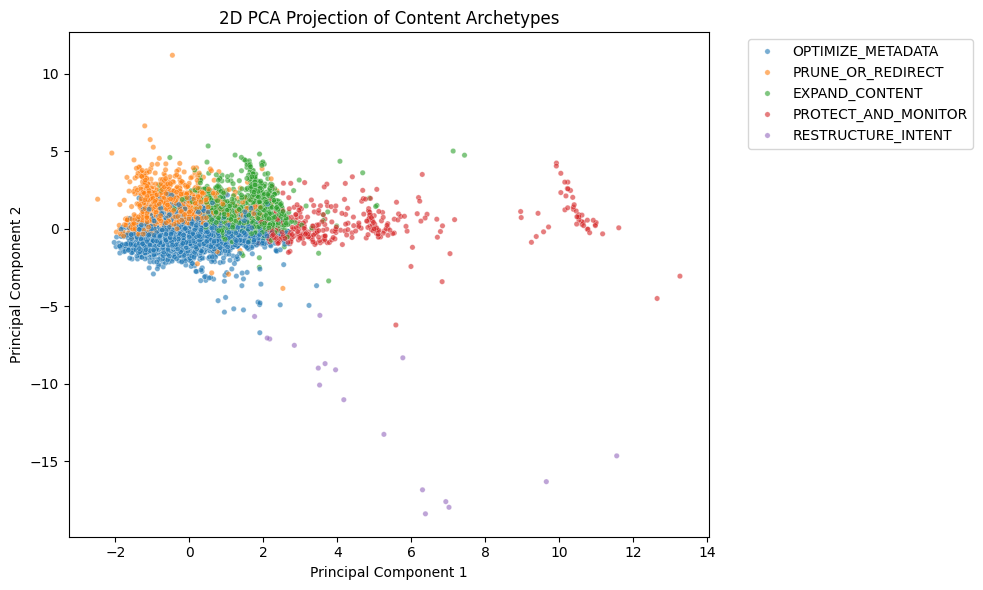

/tmp/ipykernel_6855/71638090.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


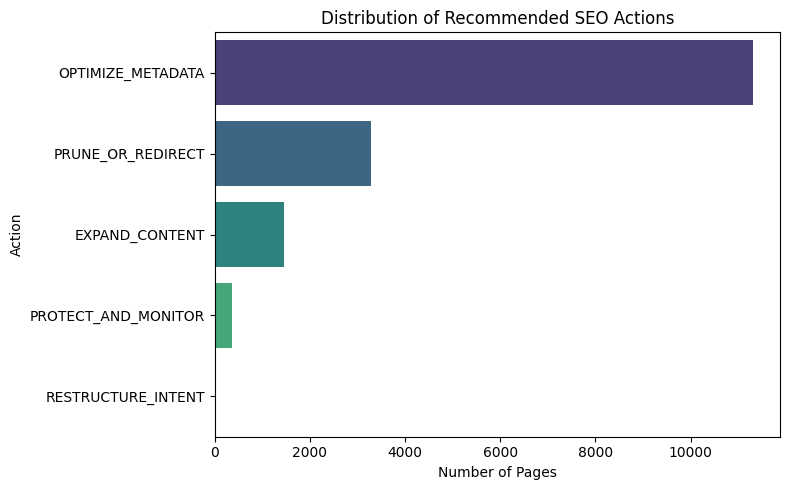

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# 1. PCA for 2D Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_clean["pca_1"] = X_pca[:, 0]
df_clean["pca_2"] = X_pca[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_clean,
    x="pca_1", y="pca_2",
    hue="recommended_action",
    palette="tab10",
    alpha=0.6, s=15
)
plt.title("2D PCA Projection of Content Archetypes")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 2. Action Distribution Chart
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_clean,
    y="recommended_action",
    order=df_clean["recommended_action"].value_counts().index,
    palette="viridis"
)
plt.title("Distribution of Recommended SEO Actions")
plt.xlabel("Number of Pages")
plt.ylabel("Action")
plt.tight_layout()
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
